In [1]:
!pip install faker --quiet

import random
import re
import pandas as pd
from faker import Faker
from typing import List, Tuple, Set


fake = Faker()
Faker.seed(42)
random.seed(42)


JOB_KEYWORDS = {
    "Software Engineer": [
        "Java", "C++", "Python", "Go", "Rust", "Git", "System Design", "Algorithms",
        "Data Structures", "Docker", "Kubernetes", "CI/CD", "Microservices", "REST APIs",
        "HTTP", "Multithreading", "Concurrency", "OAuth", "PostgreSQL", "MySQL", "NoSQL",
        "Testing", "Unit Tests", "TDD", "Design Patterns", "Scalable Systems"
    ],
    "Product Manager": [
        "Roadmap", "Stakeholder Management", "Analytics", "Agile", "Scrum", "A/B Testing",
        "Wireframes", "User Stories", "OKRs", "KPIs", "Prioritization", "Product Strategy",
        "Go-to-market", "Market Research", "Customer Interviews", "Feature Scoping",
        "Revenue", "Monetization", "Product Metrics", "User Feedback", "Competitive Analysis"
    ],
    "Designer": [
        "Figma", "Sketch", "Adobe XD", "Photoshop", "Illustrator", "InDesign", "Prototyping",
        "UX Research", "User Testing", "Information Architecture", "Visual Design",
        "Interaction Design", "Design Systems", "Accessibility", "Typography",
        "Branding", "Wireframing", "User Flows", "High-fidelity", "Responsive Design"
    ]
}
ALL_CATEGORIES = list(JOB_KEYWORDS.keys())


def make_email(name: str) -> str:
    username = re.sub(r'[^a-z0-9]', '.', name.lower().replace(" ", "."))
    username = re.sub(r'\.+', '.', username).strip('.')
    domain = random.choice(["gmail.com", "hotmail.com", "example.com", "outlook.com", "icloud.com"])
    return f"{username}.{random.randint(1,9999)}@{domain}"

def truncate_to_word_limit(text: str, max_words: int = 80) -> str:
    words = text.split()
    if len(words) <= max_words:
        return text
    return " ".join(words[:max_words])

def pick_non_target_keywords(target: str, k: int) -> List[str]:
    others = [kw for cat, kws in JOB_KEYWORDS.items() if cat != target for kw in kws]
    if len(others) == 0:
        others = OTHER_PHRASES
    return random.sample(others, min(k, len(others)))

SUMMARY_TEMPLATES = [
    "Experienced {} with a strong background in {} and {}.",
    "{} specializing in {} with experience delivering {}.",
    "Practical {} skilled in {} and {}.",
    "{} with {} years of experience in {} and {}.",
    "Passionate {} focusing on {} and {} to deliver product impact.",
    "Research-oriented {} experienced in {} and {} for applied outcomes.",
    "Creative {} who leverages {} and {} to solve user problems.",
    "Results-driven {} with expertise in {} and a passion for {}.",
    "Dynamic and motivated {} adept at {} and {}.",
    "Seeking to apply my {} years of experience in {} to a challenging new role.",
    "A {} with a proven track record in {} and {}.",
]

WORK_TEMPLATES = [
    "Developed {} to improve {}.",
    "Led a team that implemented {} using {}.",
    "Conducted {} and reported findings in {}.",
    "Built production-ready {} and integrated with {}.",
    "Designed {} focused on {}.",
    "Performed {} for product improvements and {}.",
    "Managed {} and coordinated with {} stakeholders.",
    "Architected {} to scale {} across services.",
    "Implemented {} following {} best practices.",
    "Optimized {} achieving {} improvement in {}.",
    "Designed experiments on {} and analyzed {}.",
    "Prototyped {} and tested with {} users.",
    "Authored {} submitted to {}.",
    "Automated {} in the {} pipeline.",
    # New additions
    "Collaborated with {} teams to deliver {} on schedule.",
    "Analyzed {} to identify key opportunities for {}.",
    "Drove the development of {} from concept to launch.",
    "Overhauled the existing {} to increase {}.",
    "Mentored junior team members in {} and {}.",
]

# New template category for skills
SKILL_TEMPLATES = [
    "Core competencies include {}, {}, and {}.",
    "Proficient in: {}, {}, {}.",
    "Expertise in {} and {}."
]

BULLET_ACTIONS = [
    "Improved", "Reduced", "Increased", "Automated", "Published", "Designed",
    "Implemented", "Measured", "Validated", "Scaled", "Refactored",
    "Pioneered", "Overhauled", "Streamlined", "Launched", "Negotiated"
]
BULLET_METRICS = [
    "performance", "latency", "accuracy", "user conversions", "throughput",
    "citation count", "engagement", "retention", "test coverage",
    "customer satisfaction", "system uptime", "revenue growth", "cost savings"
]
OTHER_PHRASES = [
    "cross-functional teams", "scalable systems", "large datasets", "user research",
    "experimental setups", "cloud infrastructure", "CI pipelines", "data pipelines",
    "mobile platforms", "web platforms", "stakeholder feedback", "production metrics",
    "end-to-end solutions", "industry best practices", "agile environments", "data-driven insights",
    "user-centric design", "technical specifications", "market trends"
]


def fill_template_with_args(tmpl: str, args: List[str]) -> str:
    n_placeholders = tmpl.count("{}")

    while len(args) < n_placeholders:
        args.append(random.choice(sum(JOB_KEYWORDS.values(), []) + OTHER_PHRASES))

    return tmpl.format(*args[:n_placeholders])


def generate_resume_text(
    target_category: str,
    positive: bool,
    max_words: int = 80,
    min_sentences: int = 3,
    max_sentences: int = 6
) -> Tuple[str, List[str]]:
    sentences = []
    num_sentences = random.randint(min_sentences, max_sentences)

    if positive:
        n_kw = random.randint(2, 5)
        kws = random.sample(JOB_KEYWORDS[target_category], min(n_kw, len(JOB_KEYWORDS[target_category])))
    else:
        kws = pick_non_target_keywords(target_category, random.randint(2, 4))

    keywords_used = kws.copy()

    for i in range(num_sentences):
        if i == 0:
            tmpl = random.choice(SUMMARY_TEMPLATES)
            k1 = random.choice(kws)
            k2 = random.choice(sum(JOB_KEYWORDS.values(), []) + OTHER_PHRASES)

            if "years" in tmpl:
                years = f"{random.randint(1,12)}+ years"
                sentence = fill_template_with_args(tmpl, [target_category, years, k1])
            else:
                sentence = fill_template_with_args(tmpl, [target_category, k1, k2])

        elif random.random() < 0.25:
            tmpl = random.choice(SKILL_TEMPLATES)
            skill_args = random.sample(kws, min(len(kws), tmpl.count("{}")))
            sentence = fill_template_with_args(tmpl, skill_args)

        else:
            tmpl = random.choice(WORK_TEMPLATES)
            arg1 = random.choice(kws)
            arg2 = random.choice(OTHER_PHRASES + [random.choice(sum(JOB_KEYWORDS.values(), []))])
            arg3 = random.choice(OTHER_PHRASES + [random.choice(sum(JOB_KEYWORDS.values(), []))])
            sentence = fill_template_with_args(tmpl, [arg1, arg2, arg3])

        sentences.append(sentence)

    bullets = []
    num_bullets = random.choices([0,1,2], weights=[0.4, 0.4, 0.2])[0]
    for _ in range(num_bullets):
        action = random.choice(BULLET_ACTIONS)
        metric = random.choice(BULLET_METRICS)
        by = random.choice(["by 25%", "by 40%", "three-fold", "significantly", "measurably"])
        kw = random.choice(keywords_used + OTHER_PHRASES)
        bullets.append(f"• {action} {metric} {by} through the implementation of {kw}.")

    text_parts = sentences + bullets
    random.shuffle(text_parts)
    text = " ".join(text_parts)
    text = truncate_to_word_limit(text, max_words)
    text = re.sub(r'\s+', ' ', text).strip()
    return text, keywords_used

def generate_balanced_dataset(per_class: int = 100, enforce_unique_texts: bool = True, max_attempts_per_item: int = 50) -> pd.DataFrame:
    records = []
    seen_texts: Set[str] = set()

    for job_cat in ALL_CATEGORIES:
        for positive in [True, False]:
            print(f"Generating {per_class} {'positive' if positive else 'negative'} samples for {job_cat}...")
            produced = 0
            attempts = 0
            while produced < per_class and attempts < per_class * max_attempts_per_item:
                attempts += 1
                name = fake.name()
                email = make_email(name)
                resume_text, kws_used = generate_resume_text(job_cat, positive)

                if enforce_unique_texts and resume_text in seen_texts:
                    continue

                text_lower = resume_text.lower()
                target_kw_present = any(re.search(r'\b' + re.escape(kw.lower()) + r'\b', text_lower) for kw in JOB_KEYWORDS[job_cat])

                if positive and not target_kw_present:
                    continue
                if (not positive) and target_kw_present:
                    continue

                records.append({
                    "name": name,
                    "email": email,
                    "job_category": job_cat,
                    "resume_text": resume_text,
                    "keywords_used": kws_used,
                    "label": 1 if positive else 0
                })
                produced += 1
                if enforce_unique_texts:
                    seen_texts.add(resume_text)

            if produced < per_class:
                print(f"Warning: for category '{job_cat}' positive={positive} only produced {produced}/{per_class} after {attempts} attempts.")

    df = pd.DataFrame(records)
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    return df

# --- Main Execution ---
print("Generating enhanced balanced dataset...")
df = generate_balanced_dataset(per_class=1500)
print("\n" + "="*50)
print(f"Generated a total of {len(df)} records.")
print("\nLabel distribution:\n", df['label'].value_counts())
print("\nPer-category counts:\n", df['job_category'].value_counts())

df['word_count'] = df['resume_text'].apply(lambda t: len(t.split()))
print("\nMax words in resume_text:", df['word_count'].max())
print("\nSample record:\n", df.iloc[0].to_dict())

out_filename = "synthetic_resumes_enhanced.csv"
df.drop(columns=['word_count']).to_csv(out_filename, index=False)
print(f"\nSaved enhanced dataset to '{out_filename}'.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 39.2 MB/s eta 0:00:00
Generating enhanced balanced dataset...
Generating 1500 positive samples for Software Engineer...
Generating 1500 negative samples for Software Engineer...
Generating 1500 positive samples for Product Manager...
Generating 1500 negative samples for Product Manager...
Generating 1500 positive samples for Designer...
Generating 1500 negative samples for Designer...

Generated a total of 9000 records.

Label distribution:
 label
0    4500
1    4500
Name: count, dtype: int64

Per-category counts:
 job_category
Designer             3000
Software Engineer    3000
Product Manager      3000
Name: count, dtype: int64

Max words in resume_text: 80

Sample record:
 {'name': 'Hannah Newton', 'email': 'hannah.newton.9770@hotmail.com', 'job_category': 'Designer', 'resume_text': '• Published cost savings measurably through the implementation of Go. Drove the development of Go from concept to launch. Research-oriented Designe

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import AdamW
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
import warnings
import numpy as np
from tqdm.notebook import tqdm
import json
import copy
import math

!pip install opacus -q
from opacus.accountants import RDPAccountant

warnings.simplefilter("ignore")

# Load data
try:
    df = pd.read_csv("synthetic_resumes_enhanced.csv")
except FileNotFoundError:
    print("Error: 'synthetic_resumes_enhanced.csv' not found.")
    exit()

gpu_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cpu_device = torch.device("cpu")

job_categories = df['job_category'].unique().tolist()
job2idx = {j: i for i, j in enumerate(job_categories)}
df['job_idx'] = df['job_category'].map(job2idx)

def tokenize(text): return text.lower().split()
all_tokens = [tok for text in df['resume_text'] for tok in tokenize(text)]
vocab = {tok: idx + 1 for idx, tok in enumerate(set(all_tokens))}
UNK_IDX = len(vocab) + 1
VOCAB_SIZE = UNK_IDX + 1
def encode(text): return [vocab.get(tok, UNK_IDX) for tok in tokenize(text)]

class ResumeDataset(Dataset):
    def __init__(self, texts, cat_indices, labels):
        self.texts = [torch.tensor(encode(t), dtype=torch.long) for t in texts]
        self.cats = torch.tensor(cat_indices, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float32)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.texts[idx], self.cats[idx], self.labels[idx]

def collate_bow(batch):
    texts, cats, labels = zip(*batch)
    labels = torch.tensor(labels, dtype=torch.float32)
    cats = torch.tensor(cats, dtype=torch.long)
    offsets = [0] + [len(text) for text in texts]
    offsets = torch.tensor(offsets[:-1]).cumsum(dim=0)
    texts = torch.cat(texts)
    return texts, offsets, cats, labels

dataset = ResumeDataset(df['resume_text'].tolist(), df['job_idx'].tolist(), df['label'].tolist())
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# BoW
class BagOfWordsClassifier(nn.Module):
    def __init__(self, vocab_size, num_categories, embed_dim=256, cat_embed_dim=64):
        super().__init__()
        self.text_embedding = nn.EmbeddingBag(vocab_size, embed_dim, sparse=False, padding_idx=0)
        self.cat_embedding = nn.Embedding(num_categories, cat_embed_dim)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim + cat_embed_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1)
        )
    def forward(self, texts, offsets, cat_idx):
        text_vec = self.text_embedding(texts, offsets)
        cat_vec = self.cat_embedding(cat_idx)
        combined = torch.cat([text_vec, cat_vec], dim=1)
        logits = self.classifier(combined)
        return logits.squeeze(-1)

# Helper Funcs
def eval_model(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for texts, offsets, cats, labels in loader:
            texts, offsets, cats, labels = texts.to(device), offsets.to(device), cats.to(device), labels.to(device)
            logits = model(texts, offsets, cats)
            y_hat = torch.sigmoid(logits).cpu().numpy()
            y_true.extend(labels.cpu().numpy())
            y_pred.extend((y_hat > 0.5).astype(int))
    return {"accuracy": accuracy_score(y_true, y_pred), "f1": f1_score(y_true, y_pred, zero_division=0)}

def train_baseline_robust(config):
    print("\n" + "="*50 + "\nRunning Improved Non-Private Baseline Training...\n" + "="*50)
    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True, collate_fn=collate_bow)
    val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], collate_fn=collate_bow)
    test_loader = DataLoader(test_dataset, batch_size=config['batch_size'], collate_fn=collate_bow)
    model = BagOfWordsClassifier(VOCAB_SIZE, len(job_categories)).to(gpu_device)
    optimizer = AdamW(model.parameters(), lr=config['lr'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)
    criterion = nn.BCEWithLogitsLoss()
    best_val_f1 = -1
    patience_counter = 0
    best_model_state = None
    for epoch in range(config['epochs']):
        model.train()
        for texts, offsets, cats, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{config['epochs']}"):
            texts, offsets, cats, labels = texts.to(gpu_device), offsets.to(gpu_device), cats.to(gpu_device), labels.to(gpu_device)
            optimizer.zero_grad()
            logits = model(texts, offsets, cats)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
        val_metrics = eval_model(model, val_loader, gpu_device)
        val_f1 = val_metrics['f1']
        print(f"Epoch {epoch+1}: Val F1: {val_f1:.4f}, Current LR: {optimizer.param_groups[0]['lr']:.2E}")
        scheduler.step(val_f1)
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                break
    model.load_state_dict(best_model_state)
    test_metrics = eval_model(model, test_loader, gpu_device)
    print(f"\nBASELINE RESULTS:\n  -> Final Test Accuracy: {test_metrics['accuracy']:.4f}\n  -> Final Test F1 Score: {test_metrics['f1']:.4f}")
    return test_metrics

def find_adaptive_clip_norm(model, loader, device):
    print("\n--- Running epoch to find adaptive clipping norm ---")
    model.train()
    criterion = nn.BCEWithLogitsLoss()
    norms = []
    for texts, offsets, cats, labels in tqdm(loader, desc="Analyzing Gradients"):
        batch_size = len(labels)
        for i in range(batch_size):
            text_end = offsets[i+1] if i+1 < len(offsets) else len(texts)
            text_i, offset_i, cat_i, label_i = texts[offsets[i]:text_end], torch.tensor([0]), cats[i:i+1], labels[i:i+1]
            model.zero_grad()
            logit_i = model(text_i.to(device), offset_i.to(device), cat_i.to(device))
            loss_i = criterion(logit_i, label_i.to(device))
            loss_i.backward()
            total_norm = sum(p.grad.norm(2).item() ** 2 for p in model.parameters() if p.grad is not None) ** 0.5
            norms.append(total_norm)
    median_norm = np.median(norms)
    print(f"--- Found median gradient norm: {median_norm:.4f} ---")
    return median_norm

def train_manual_dp(model, loader, optimizer, criterion, device, clip_norm, noise_multiplier):
    model.train()
    for texts, offsets, cats, labels in tqdm(loader, desc="DP Batch"):
        batch_size = len(labels)
        saved_grads = {name: [] for name, param in model.named_parameters() if param.requires_grad}
        for i in range(batch_size):
            optimizer.zero_grad()
            text_end = offsets[i+1] if i+1 < len(offsets) else len(texts)
            text_i, offset_i, cat_i, label_i = texts[offsets[i]:text_end], torch.tensor([0]), cats[i:i+1], labels[i:i+1]
            logit_i = model(text_i.to(device), offset_i.to(device), cat_i.to(device))
            loss_i = criterion(logit_i, label_i.to(device))
            loss_i.backward()
            for name, param in model.named_parameters():
                if param.requires_grad and param.grad is not None:
                    saved_grads[name].append(param.grad.clone())
        optimizer.zero_grad()
        for i in range(batch_size):
            total_norm = sum(saved_grads[name][i].norm(2).item() ** 2 for name, _ in model.named_parameters() if name in saved_grads and i < len(saved_grads[name])) ** 0.5
            clip_factor = min(1.0, clip_norm / (total_norm + 1e-6))
            for name, _ in model.named_parameters():
                 if name in saved_grads and i < len(saved_grads[name]):
                    saved_grads[name][i].mul_(clip_factor)
        for name, param in model.named_parameters():
            if name in saved_grads and saved_grads[name]:
                clipped_sum = torch.stack(saved_grads[name], dim=0).sum(dim=0)
                noise = torch.normal(0, clip_norm * noise_multiplier, size=clipped_sum.shape, device=device)
                param.grad = (clipped_sum + noise) / batch_size
        optimizer.step()




baseline_config = {'lr': 1e-3, 'batch_size': 128, 'epochs': 20, 'patience': 5}
baseline_metrics = train_baseline_robust(baseline_config)

DP_BATCH_SIZE = 256
DP_EPOCHS = 8

temp_model = BagOfWordsClassifier(VOCAB_SIZE, len(job_categories)).to(cpu_device)
temp_loader = DataLoader(train_dataset, batch_size=DP_BATCH_SIZE, shuffle=True, collate_fn=collate_bow)
adaptive_c = find_adaptive_clip_norm(temp_model, temp_loader, cpu_device)

### The following block was used for testing different hyperparameters. Added the table to readme but commented it out as the next cell runs on the main grid

# Custom SWEEP grid
# CLIP_NORMS = sorted(list(set([0.5, 1.0, round(adaptive_c, 2)])))
# NOISE_MULTIPLIERS = [0.8, 1.2, 1.5]
# LEARNING_RATES = [5e-3, 1e-4]

# print(f"\nStarting grid sweep with C values: {CLIP_NORMS}")

# results = []

# for lr in LEARNING_RATES:
#     for c in CLIP_NORMS:
#         for sigma in NOISE_MULTIPLIERS:
#             print("\n" + "-" * 50 + f"\nStarting DP-SGD Sweep Run...")
#             print(f"Params: C={c}, σ={sigma}, BS={DP_BATCH_SIZE}, LR={lr}")
#             print("-" * 50)

#             dp_model = BagOfWordsClassifier(VOCAB_SIZE, len(job_categories)).to(cpu_device)
#             dp_optimizer = AdamW(dp_model.parameters(), lr=lr)
#             dp_criterion = nn.BCEWithLogitsLoss()

#             train_loader_cpu = DataLoader(train_dataset, batch_size=DP_BATCH_SIZE, shuffle=True, collate_fn=collate_bow)
#             test_loader_cpu = DataLoader(test_dataset, batch_size=DP_BATCH_SIZE, collate_fn=collate_bow)

#             accountant = RDPAccountant()
#             DELTA = 1 / len(train_dataset)
#             sample_rate = DP_BATCH_SIZE / len(train_dataset)

#             for epoch in range(DP_EPOCHS):
#                 train_manual_dp(dp_model, train_loader_cpu, dp_optimizer, dp_criterion, cpu_device, c, sigma)
#                 accountant.step(noise_multiplier=sigma, sample_rate=sample_rate)
#                 epsilon = accountant.get_epsilon(delta=DELTA)
#                 print(f"Epoch {epoch+1}/{DP_EPOCHS} | Epsilon: {epsilon:.2f}")

#             dp_metrics = eval_model(dp_model, test_loader_cpu, cpu_device)
#             final_epsilon = accountant.get_epsilon(delta=DELTA)

#             print("\n" + "---" * 15)
#             print(f"Result for Run (C={c}, σ={sigma}, LR={lr}):")
#             print(f"  -> Final Test Accuracy: {dp_metrics['accuracy']:.4f}")
#             print(f"  -> Final Test F1 Score: {dp_metrics['f1']:.4f}")
#             print(f"  -> Final Epsilon (ε): {final_epsilon:.2f}")
#             print("---" * 15)

#             results.append({
#                 "lr": lr, "clip_norm": c, "noise_multiplier": sigma,
#                 "final_epsilon": final_epsilon, "accuracy": dp_metrics['accuracy'], "f1": dp_metrics['f1']
#             })

# # 3. Report Final Comparison
# results_df = pd.DataFrame(results).rename(columns={"accuracy": "test_accuracy", "f1": "test_f1"})
# display_cols = ['lr', 'clip_norm', 'noise_multiplier', 'final_epsilon', 'test_accuracy', 'test_f1']
# results_df = results_df[display_cols].sort_values(by="test_f1", ascending=False)

# print("\n\n" + "=" * 80 + "\n        Final Tuned Sweep Results: Baseline vs. DP-SGD\n" + "=" * 80)
# print(f"BASELINE MODEL (Bag-of-Words, Non-Private):")
# print(f"  Accuracy: {baseline_metrics['accuracy']:.4f}")
# print(f"  F1 Score: {baseline_metrics['f1']:.4f}\n")
# print(f"DP-SGD MODELS (Bag-of-Words, Private, δ≈{DELTA:.2E}):")
# print(results_df.to_string(index=False))
# print("=" * 80)

In [13]:
def train_baseline_robust(config): # for storing epoch wise scores (takes longer)
    print("\n" + "="*50 + "\nRunning Improved Non-Private Baseline Training...\n" + "="*50)
    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True, collate_fn=collate_bow)
    val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], collate_fn=collate_bow)
    test_loader = DataLoader(test_dataset, batch_size=config['batch_size'], collate_fn=collate_bow)
    model = BagOfWordsClassifier(VOCAB_SIZE, len(job_categories)).to(gpu_device)
    optimizer = AdamW(model.parameters(), lr=config['lr'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)
    criterion = nn.BCEWithLogitsLoss()
    best_val_f1 = -1
    patience_counter = 0
    best_model_state = None
    history = []
    for epoch in range(config['epochs']):
        model.train()
        for texts, offsets, cats, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{config['epochs']}"):
            texts, offsets, cats, labels = texts.to(gpu_device), offsets.to(gpu_device), cats.to(gpu_device), labels.to(gpu_device)
            optimizer.zero_grad()
            logits = model(texts, offsets, cats)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

        val_metrics = eval_model(model, val_loader, gpu_device)
        val_f1 = val_metrics['f1']
        history.append({'epoch': epoch + 1, 'val_accuracy': val_metrics['accuracy'], 'val_f1': val_f1})

        print(f"Epoch {epoch+1}: Val F1: {val_f1:.4f}, Current LR: {optimizer.param_groups[0]['lr']:.2E}")
        scheduler.step(val_f1)
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                print(f"--- Early stopping triggered. ---")
                break
    print("\nLoading best model and evaluating on the test set...")
    model.load_state_dict(best_model_state)
    test_metrics = eval_model(model, test_loader, gpu_device)
    print(f"\nIMPROVED BASELINE RESULTS:\n  -> Final Test Accuracy: {test_metrics['accuracy']:.4f}\n  -> Final Test F1 Score: {test_metrics['f1']:.4f}")
    return model, test_metrics, pd.DataFrame(history)

########

baseline_config = {'lr': 1e-3, 'batch_size': 128, 'epochs': 50, 'patience': 5}
baseline_model, baseline_metrics, baseline_history = train_baseline_robust(baseline_config)

DP_BATCH_SIZE = 256
DP_EPOCHS = 15

temp_model = BagOfWordsClassifier(VOCAB_SIZE, len(job_categories)).to(cpu_device)
temp_loader = DataLoader(train_dataset, batch_size=DP_BATCH_SIZE, shuffle=True, collate_fn=collate_bow)
adaptive_c = find_adaptive_clip_norm(temp_model, temp_loader, cpu_device)

CLIP_NORMS = sorted(list(set([0.5, 1.0, round(adaptive_c, 2)])))
NOISE_MULTIPLIERS = [0.5, 1, 2]
LEARNING_RATES = [5e-3]

print(f"\nStarting grid sweep with C values: {CLIP_NORMS}")

results = []
all_dp_histories = {}

for lr in LEARNING_RATES:
    for c in CLIP_NORMS:
        for sigma in NOISE_MULTIPLIERS:
            run_id = f"C={c}, σ={sigma}, LR={lr}"
            print("\n" + "-" * 50 + f"\nStarting DP-SGD Sweep Run: {run_id}")

            dp_model = BagOfWordsClassifier(VOCAB_SIZE, len(job_categories)).to(cpu_device)
            dp_optimizer = AdamW(dp_model.parameters(), lr=lr)
            dp_criterion = nn.BCEWithLogitsLoss()

            train_loader_cpu = DataLoader(train_dataset, batch_size=DP_BATCH_SIZE, shuffle=True, collate_fn=collate_bow)
            test_loader_cpu = DataLoader(test_dataset, batch_size=DP_BATCH_SIZE, collate_fn=collate_bow)

            accountant = RDPAccountant()
            DELTA = 1 / len(train_dataset)
            sample_rate = DP_BATCH_SIZE / len(train_dataset)

            history = []
            for epoch in range(DP_EPOCHS):
                train_manual_dp(dp_model, train_loader_cpu, dp_optimizer, dp_criterion, cpu_device, c, sigma)
                accountant.step(noise_multiplier=sigma, sample_rate=sample_rate)
                epsilon = accountant.get_epsilon(delta=DELTA)

                epoch_metrics = eval_model(dp_model, test_loader_cpu, cpu_device)
                history.append({
                    'epoch': epoch + 1,
                    'accuracy': epoch_metrics['accuracy'],
                    'epsilon': epsilon
                })
                print(f"Epoch {epoch+1}/{DP_EPOCHS} | Epsilon: {epsilon:.2f} | Test Accuracy: {epoch_metrics['accuracy']:.4f}")

            all_dp_histories[run_id] = pd.DataFrame(history)
            final_metrics = history[-1]

            results.append({
                "run_id": run_id, "lr": lr, "clip_norm": c, "noise_multiplier": sigma,
                "final_epsilon": final_metrics['epsilon'], "accuracy": final_metrics['accuracy'], "f1": eval_model(dp_model, test_loader_cpu, cpu_device)['f1']
            })

results_df = pd.DataFrame(results).rename(columns={"accuracy": "test_accuracy", "f1": "test_f1"})
display_cols = ['run_id', 'lr', 'clip_norm', 'noise_multiplier', 'final_epsilon', 'test_accuracy', 'test_f1']
results_df = results_df[display_cols].sort_values(by="test_f1", ascending=False)



Running Improved Non-Private Baseline Training...


Epoch 1/50:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1: Val F1: 0.8764, Current LR: 1.00E-03


Epoch 2/50:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 2: Val F1: 0.9449, Current LR: 1.00E-03


...

Epoch 13/15 | Epsilon: 0.31 | Test Accuracy: 0.7267


DP Batch:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 14/15 | Epsilon: 0.32 | Test Accuracy: 0.7111


DP Batch:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 15/15 | Epsilon: 0.33 | Test Accuracy: 0.6741



                    Final Hyperparameter Results
                run_id    lr  clip_norm  noise_multiplier  final_epsilon  test_accuracy  test_f1
C=3.4, σ=0.5, LR=0.005 0.005        3.4               0.5       8.119425       0.894074 0.895697
C=1.0, σ=0.5, LR=0.005 0.005        1.0               0.5       8.119425       0.880741 0.877380
C=0.5, σ=0.5, LR=0.005 0.005        0.5               0.5       8.119425       0.858519 0.864443
  C=3.4, σ=1, LR=0.005 0.005        3.4               1.0       1.499881       0.837037 0.839884
  C=1.0, σ=1, LR=0.005 0.005        1.0               1.0       1.499881       0.794815 0.813468
  C=0.5, σ=1, LR=0.005 0.005        0.5               1.0       1.499881       0.764444 0.733668
  C=1.0, σ=2, LR=0.005 0.005        1.0               2.0       0.326025       0.704444 0.663291
  C=3.4, σ=2, LR=0.005 0.005        3.4               2.0       0.326025       0.674074 0.655712
  C=0.5, σ=2, LR=0.005 0.005        0.5               2.0       0.326025     

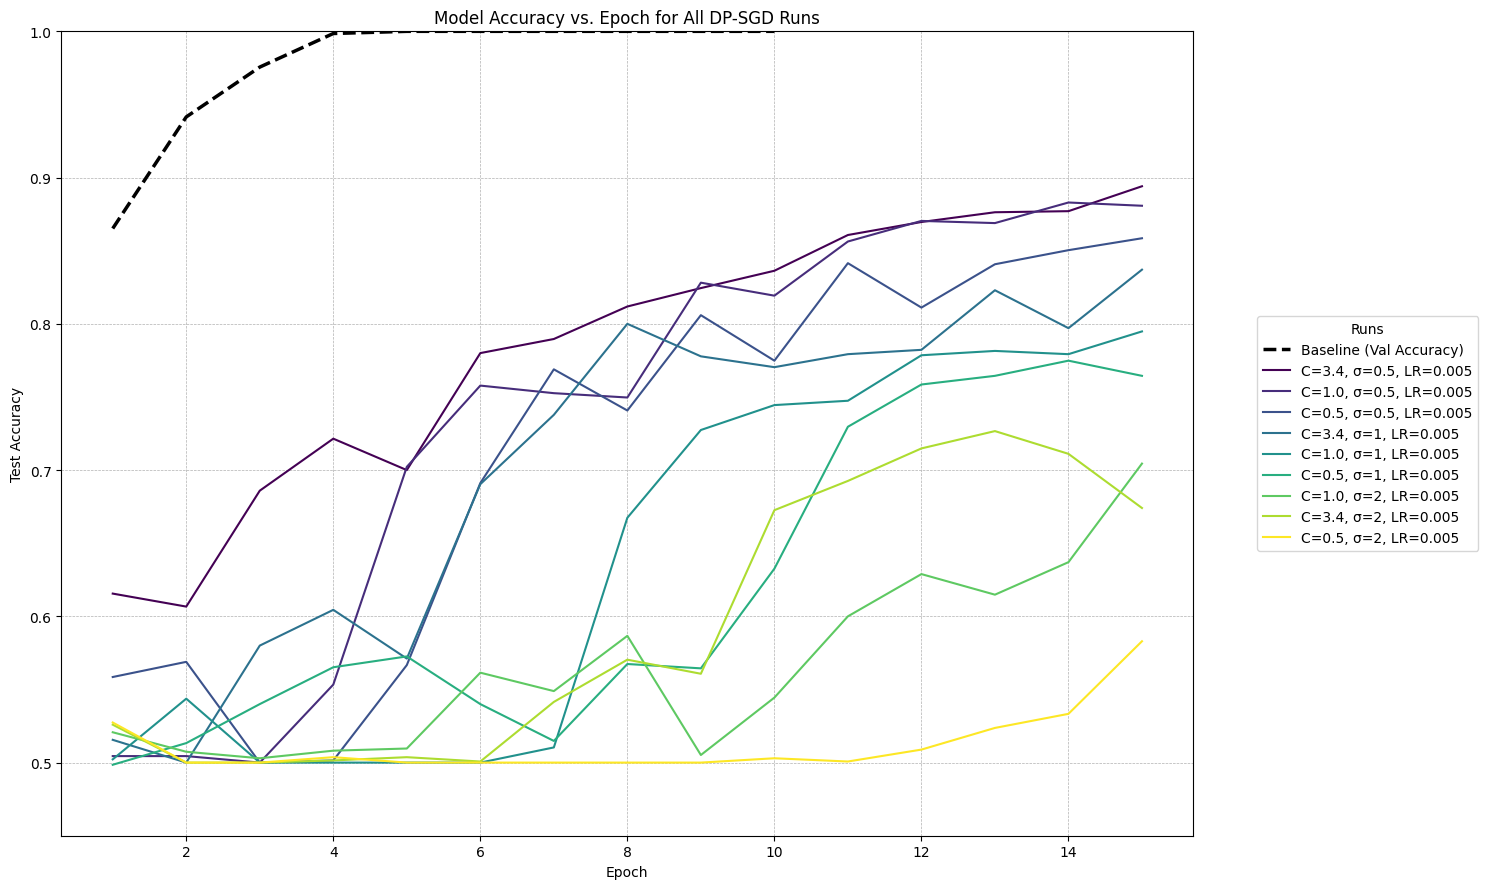

In [14]:
import matplotlib.pyplot as plt

results_df = pd.DataFrame(results).rename(columns={"accuracy": "test_accuracy", "f1": "test_f1"})

display_cols = ['run_id', 'lr', 'clip_norm', 'noise_multiplier', 'final_epsilon', 'test_accuracy', 'test_f1']
results_df = results_df[display_cols].sort_values(by="test_f1", ascending=False)

print("\n" + "="*80)
print(" " * 20 + "Final Hyperparameter Results")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

print("\n\n" + "=" * 80 + "\n        Plotting All DP-SGD Runs (Accuracy Only)...\n" + "=" * 80)

# --- Accuracy Plot ---
fig_acc, ax_acc = plt.subplots(figsize=(15, 9))
colors = plt.cm.viridis(np.linspace(0, 1, len(results_df)))

ax_acc.plot(baseline_history['epoch'], baseline_history['val_accuracy'],
         label='Baseline (Val Accuracy)', color='black', linestyle='--', linewidth=2.5, zorder=100)

for i, (idx, row) in enumerate(results_df.iterrows()):
    run_id = row['run_id']
    history_df = all_dp_histories[run_id]
    accuracy_col = 'accuracy' if 'accuracy' in history_df.columns else 'val_accuracy'
    ax_acc.plot(history_df['epoch'], history_df[accuracy_col], label=f'{run_id}', color=colors[i])

ax_acc.set_xlabel('Epoch')
ax_acc.set_ylabel('Test Accuracy')
ax_acc.set_title('Model Accuracy vs. Epoch for All DP-SGD Runs')
ax_acc.grid(True, which='both', linestyle='--', linewidth=0.5)
ax_acc.set_ylim(bottom=0.45, top=1.0)
ax_acc.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), title="Runs")

fig_acc.tight_layout()
plt.savefig("dp_sgd_accuracy_curves.png", bbox_inches='tight')
print("\nPlot saved to dp_sgd_accuracy_curves.png")
plt.show()


In [17]:
from sklearn.linear_model import LogisticRegression

# MIA with Logistic Regression Model
def compute_losses(model, loader, device):
    model.eval()
    criterion = nn.BCEWithLogitsLoss(reduction='none')
    losses = []
    with torch.no_grad():
        for texts, offsets, cats, labels in loader:
            texts, offsets, cats, labels = texts.to(device), offsets.to(device), cats.to(device), labels.to(device)
            logits = model(texts, offsets, cats)
            loss = criterion(logits, labels)
            losses.append(loss.cpu().numpy())
    return np.concatenate(losses)

def run_mia(target_model, train_loader, test_loader, device):
    member_losses = compute_losses(target_model, train_loader, device)
    non_member_losses = compute_losses(target_model, test_loader, device)

    X_attack = np.concatenate([member_losses, non_member_losses]).reshape(-1, 1)
    y_attack = np.concatenate([np.ones_like(member_losses), np.zeros_like(non_member_losses)])

    attack_model = LogisticRegression(class_weight='balanced')
    attack_model.fit(X_attack, y_attack)

    attack_accuracy = attack_model.score(X_attack, y_attack)
    return attack_accuracy

# Baseline Model
baseline_config = {'lr': 1e-3, 'batch_size': 128, 'epochs': 20, 'patience': 5}

# CORRECTED LINE: Call the function that returns the model and capture all 3 results
# Ensure you are using a version of the function that returns (model, metrics, history)
baseline_model, baseline_metrics, baseline_history = train_baseline_robust(baseline_config)

# Using the best hyperparameters from previous sweep, this has epsilon 1.5
DP_BATCH_SIZE = 256
DP_EPOCHS = 15
DP_LR = 5e-3
DP_NOISE_MULTIPLIER = 1
DP_CLIP_NORM = 3.4

print("\n" + "=" * 50 + f"\nTraining Best DP-SGD Model for MIA Comparison...\n" + "=" * 50)

dp_model = BagOfWordsClassifier(VOCAB_SIZE, len(job_categories)).to(cpu_device)
dp_optimizer = AdamW(dp_model.parameters(), lr=DP_LR)
dp_criterion = nn.BCEWithLogitsLoss()

train_loader_cpu = DataLoader(train_dataset, batch_size=DP_BATCH_SIZE, shuffle=True, collate_fn=collate_bow)
test_loader_cpu = DataLoader(test_dataset, batch_size=DP_BATCH_SIZE, collate_fn=collate_bow)

for epoch in range(DP_EPOCHS):
    train_manual_dp(dp_model, train_loader_cpu, dp_optimizer, dp_criterion, cpu_device, DP_CLIP_NORM, DP_NOISE_MULTIPLIER)
    print(f"DP Training Epoch {epoch+1}/{DP_EPOCHS} complete.")

print("\nEvaluating final DP model...")
dp_metrics = eval_model(dp_model, test_loader_cpu, cpu_device)
print(f"  -> Final DP Test Accuracy: {dp_metrics['accuracy']:.4f}\n  -> Final DP Test F1 Score: {dp_metrics['f1']:.4f}")

# Run and Compare MIAs
print("\n" + "\nRunning Membership Inference Attacks...\n")

# For equal weighting, we don't shuffle
mia_train_loader_gpu = DataLoader(train_dataset, batch_size=baseline_config['batch_size'], shuffle=False, collate_fn=collate_bow)
mia_test_loader_gpu = DataLoader(test_dataset, batch_size=baseline_config['batch_size'], shuffle=False, collate_fn=collate_bow)

mia_train_loader_cpu = DataLoader(train_dataset, batch_size=DP_BATCH_SIZE, shuffle=False, collate_fn=collate_bow)
mia_test_loader_cpu = DataLoader(test_dataset, batch_size=DP_BATCH_SIZE, collate_fn=collate_bow)

# Attack the baseline model
# This will now work correctly because `baseline_model` is a model object
baseline_mia_accuracy = run_mia(baseline_model, mia_train_loader_gpu, mia_test_loader_gpu, gpu_device)

# Attack the DP model
dp_mia_accuracy = run_mia(dp_model, mia_train_loader_cpu, mia_test_loader_cpu, cpu_device)

# --- Final Report ---
print("\n\n" + "=" * 70 + "\n        Final Report: Model Performance and MIA Vulnerability\n" + "=" * 70)
print("--- BASELINE MODEL (Non-Private) ---")
print(f"  Utility:     Accuracy={baseline_metrics['accuracy']:.4f}, F1 Score={baseline_metrics['f1']:.4f}")
print(f"  Vulnerability: MIA Accuracy={baseline_mia_accuracy:.4f}\n")

print("--- DP-SGD MODEL (Private) ---")
print(f"  Utility:     Accuracy={dp_metrics['accuracy']:.4f}, F1 Score={dp_metrics['f1']:.4f}")
print(f"  Vulnerability: MIA Accuracy={dp_mia_accuracy:.4f}\n")

print("--- Takeaway ---")
print("The non-private baseline model is highly vulnerable to Membership Inference Attacks, as shown by the high attack accuracy.")
print("The DP-SGD model is slightly against this attack,")
print("which shows the effectiveness of DP-SGD. To get lower attack accuracy, the noise multiplier has to be ramped up which again leads us to the privacy and accuracy trade-off.")
print("="*70)


Running Improved Non-Private Baseline Training...


Epoch 1/20:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1: Val F1: 0.8518, Current LR: 1.00E-03


Epoch 2/20:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 2: Val F1: 0.9584, Current LR: 1.00E-03


...

DP Training Epoch 13/15 complete.


DP Batch:   0%|          | 0/25 [00:00<?, ?it/s]

DP Training Epoch 14/15 complete.


DP Batch:   0%|          | 0/25 [00:00<?, ?it/s]

DP Training Epoch 15/15 complete.

Evaluating final DP model...
  -> Final DP Test Accuracy: 0.7985
  -> Final DP Test F1 Score: 0.7831


Running Membership Inference Attacks...



        Final Report: Model Performance and MIA Vulnerability
--- BASELINE MODEL (Non-Private) ---
  Utility:     Accuracy=0.9993, F1 Score=0.9993
  Vulnerability: MIA Accuracy=0.6993

--- DP-SGD MODEL (Private) ---
  Utility:     Accuracy=0.7985, F1 Score=0.7831
  Vulnerability: MIA Accuracy=0.6060

--- Takeaway ---
The non-private baseline model is highly vulnerable to Membership Inference Attacks, as shown by the high attack accuracy.
The DP-SGD model is slightly against this attack,
which shows the effectiveness of DP-SGD. To get lower attack accuracy, the noise multiplier has to be ramped up which again leads us to the privacy and accuracy trade-off.
